# k-Sensitivity Analysis — Full Visualization Suite (with Fairlet)
Reads `k_sensitivity.pkl` (18 datasets × 7 methods incl. **Fairlet** × k=2–10; metrics: Silhouette, Balance, SPD).

Produces, in order:
1. **Figure S1** — full grid: every dataset × 3 metrics (supplementary material)
2. **Figure 6a/6b/6c** — compact paper-ready grids: Silhouette / Balance / SPD vs k, all datasets & methods, each method's own optimum starred
3. **Summary table** (csv + xlsx): best k, endpoint values, and full range (max−min) per dataset × method
4. **k-range justification statistic**: % of dataset×method combinations whose Silhouette optimum falls strictly inside k=2–10 (vs. sitting on the upper edge)

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.spines.top']   = False
matplotlib.rcParams['axes.spines.right'] = False

PKL_PATH = 'k_sensitivity.pkl'  # adjust if needed

with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)

sweep    = data['sweep']
datasets = data['datasets']
methods  = data['methods']       # now includes 'fairlet'
k_range  = data['k_range']

METHOD_LABEL = {
    'kmeans':'K-Means', 'fairlet':'Fairlet', 'bfkm':'BFKM',
    'fair_centroid':'CCF', 'postprocessing_nfp':'PP-NFP',
    'postprocessing_gini':'PP-Gini', 'rawlsian':'Rawlsian',
}
COLORS = ['#1f77b4','#2ca02c','#d62728','#9467bd','#ff7f0e','#8c564b','#e377c2']
k_vals = list(k_range)

print('Methods:', methods)
print('Datasets:', len(datasets))

Methods: ['kmeans', 'fairlet', 'bfkm', 'fair_centroid', 'postprocessing_nfp', 'postprocessing_gini', 'rawlsian']
Datasets: 18


## Figure S1 — Full grid (every dataset × 3 metrics) — supplementary material

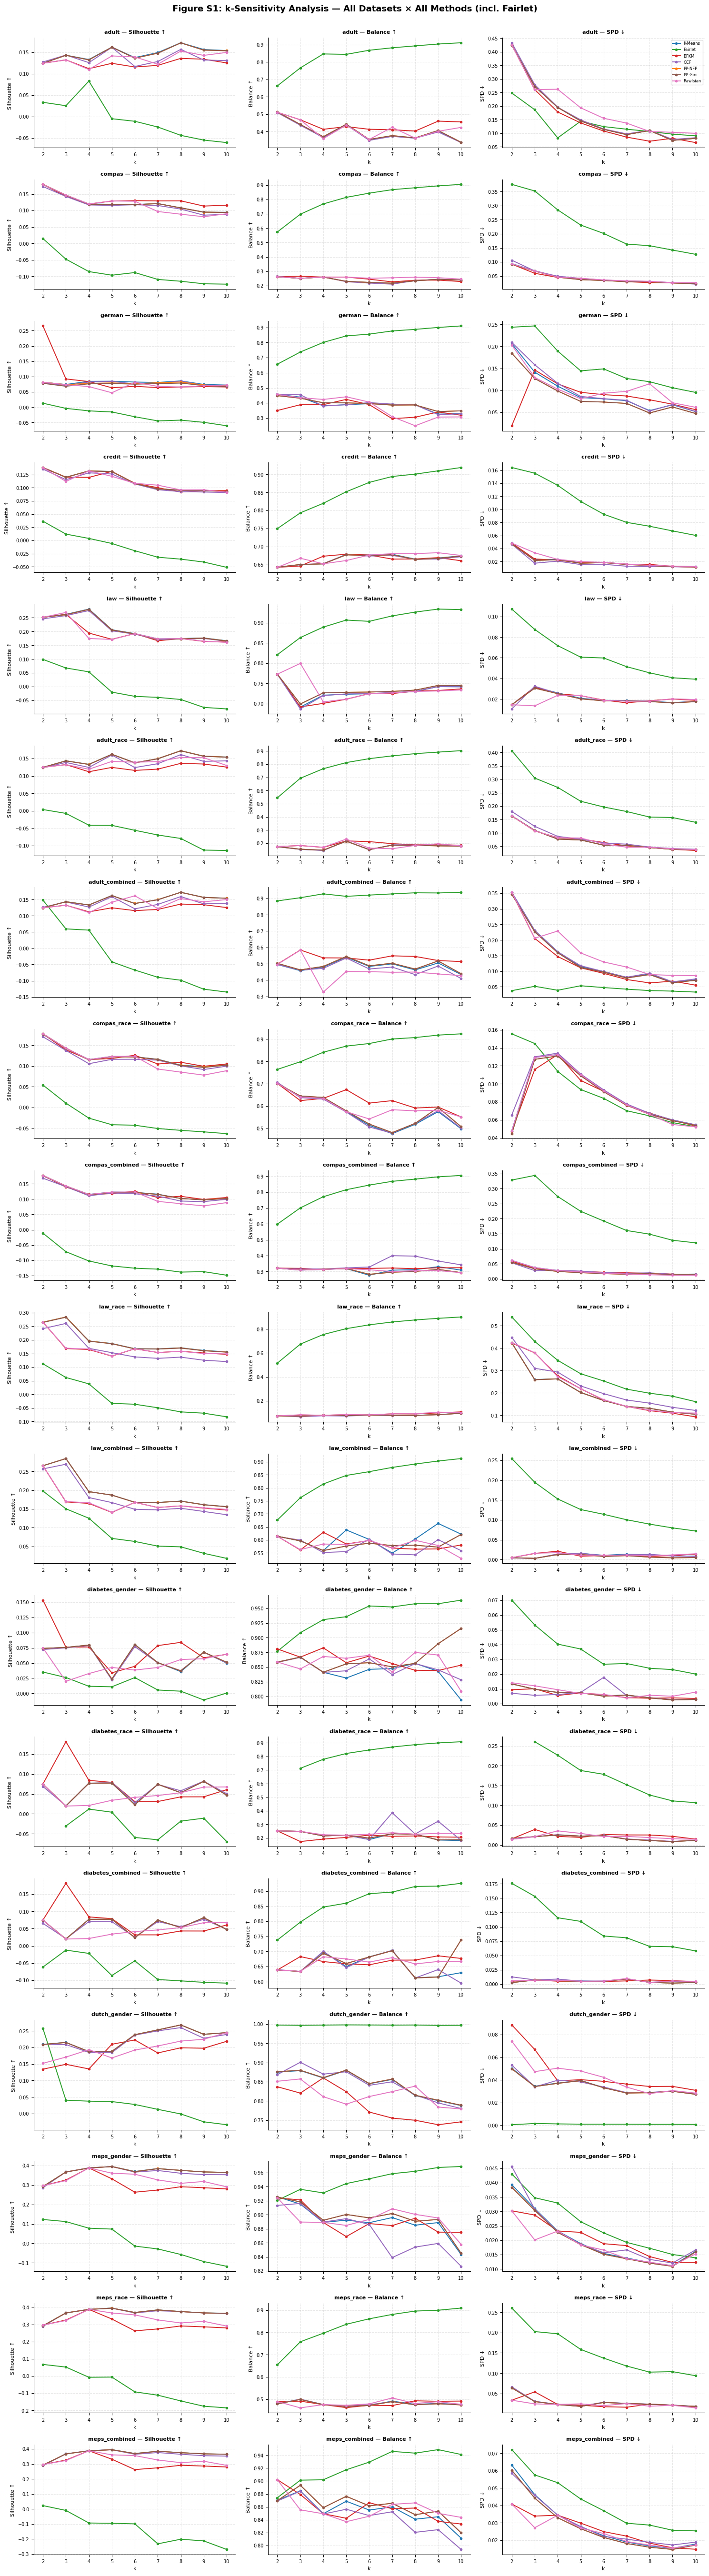

Saved FigureS1 (full grid, supplementary)


In [4]:
metrics_to_plot = [
    ('Silhouette', 'Silhouette \u2191', True),
    ('Balance',    'Balance \u2191',    True),
    ('SPD',        'SPD \u2193',        False),
]
n_ds = len(datasets)
fig, axes = plt.subplots(n_ds, 3, figsize=(15, 3.0*n_ds), squeeze=False)
fig.suptitle('Figure S1: k-Sensitivity Analysis — All Datasets × All Methods (incl. Fairlet)',
             fontsize=13, fontweight='bold', y=1.001)

for di, ds in enumerate(datasets):
    for mi, (metric, label, higher) in enumerate(metrics_to_plot):
        ax = axes[di][mi]
        for ci, method in enumerate(methods):
            recs = [r for r in sweep[ds][method] if r['status'] == 'ok']
            xs = [r['k'] for r in recs]
            ys = [r[metric] for r in recs]
            ax.plot(xs, ys, marker='o', markersize=3, linewidth=1.4,
                    color=COLORS[ci % len(COLORS)], label=METHOD_LABEL[method])
        ax.set_xlabel('k', fontsize=8)
        ax.set_ylabel(label, fontsize=8)
        ax.set_title(f'{ds} — {label}', fontsize=8, fontweight='bold')
        ax.set_xticks(k_vals)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.3, linestyle='--')
        if di == 0 and mi == 2:
            ax.legend(fontsize=6, loc='best', framealpha=0.7, ncol=1)

plt.tight_layout()
plt.savefig('FigureS1_k_sensitivity_full_grid.png', dpi=150, bbox_inches='tight')
plt.savefig('FigureS1_k_sensitivity_full_grid.pdf', bbox_inches='tight')
plt.show()
print('Saved FigureS1 (full grid, supplementary)')

## Figure 6a/6b/6c — Compact paper-ready grids
One subplot per dataset, all 7 methods overlaid. Stars mark each method's own Silhouette optimum (this is what Strategy 2's per-algorithm k selection is built on).

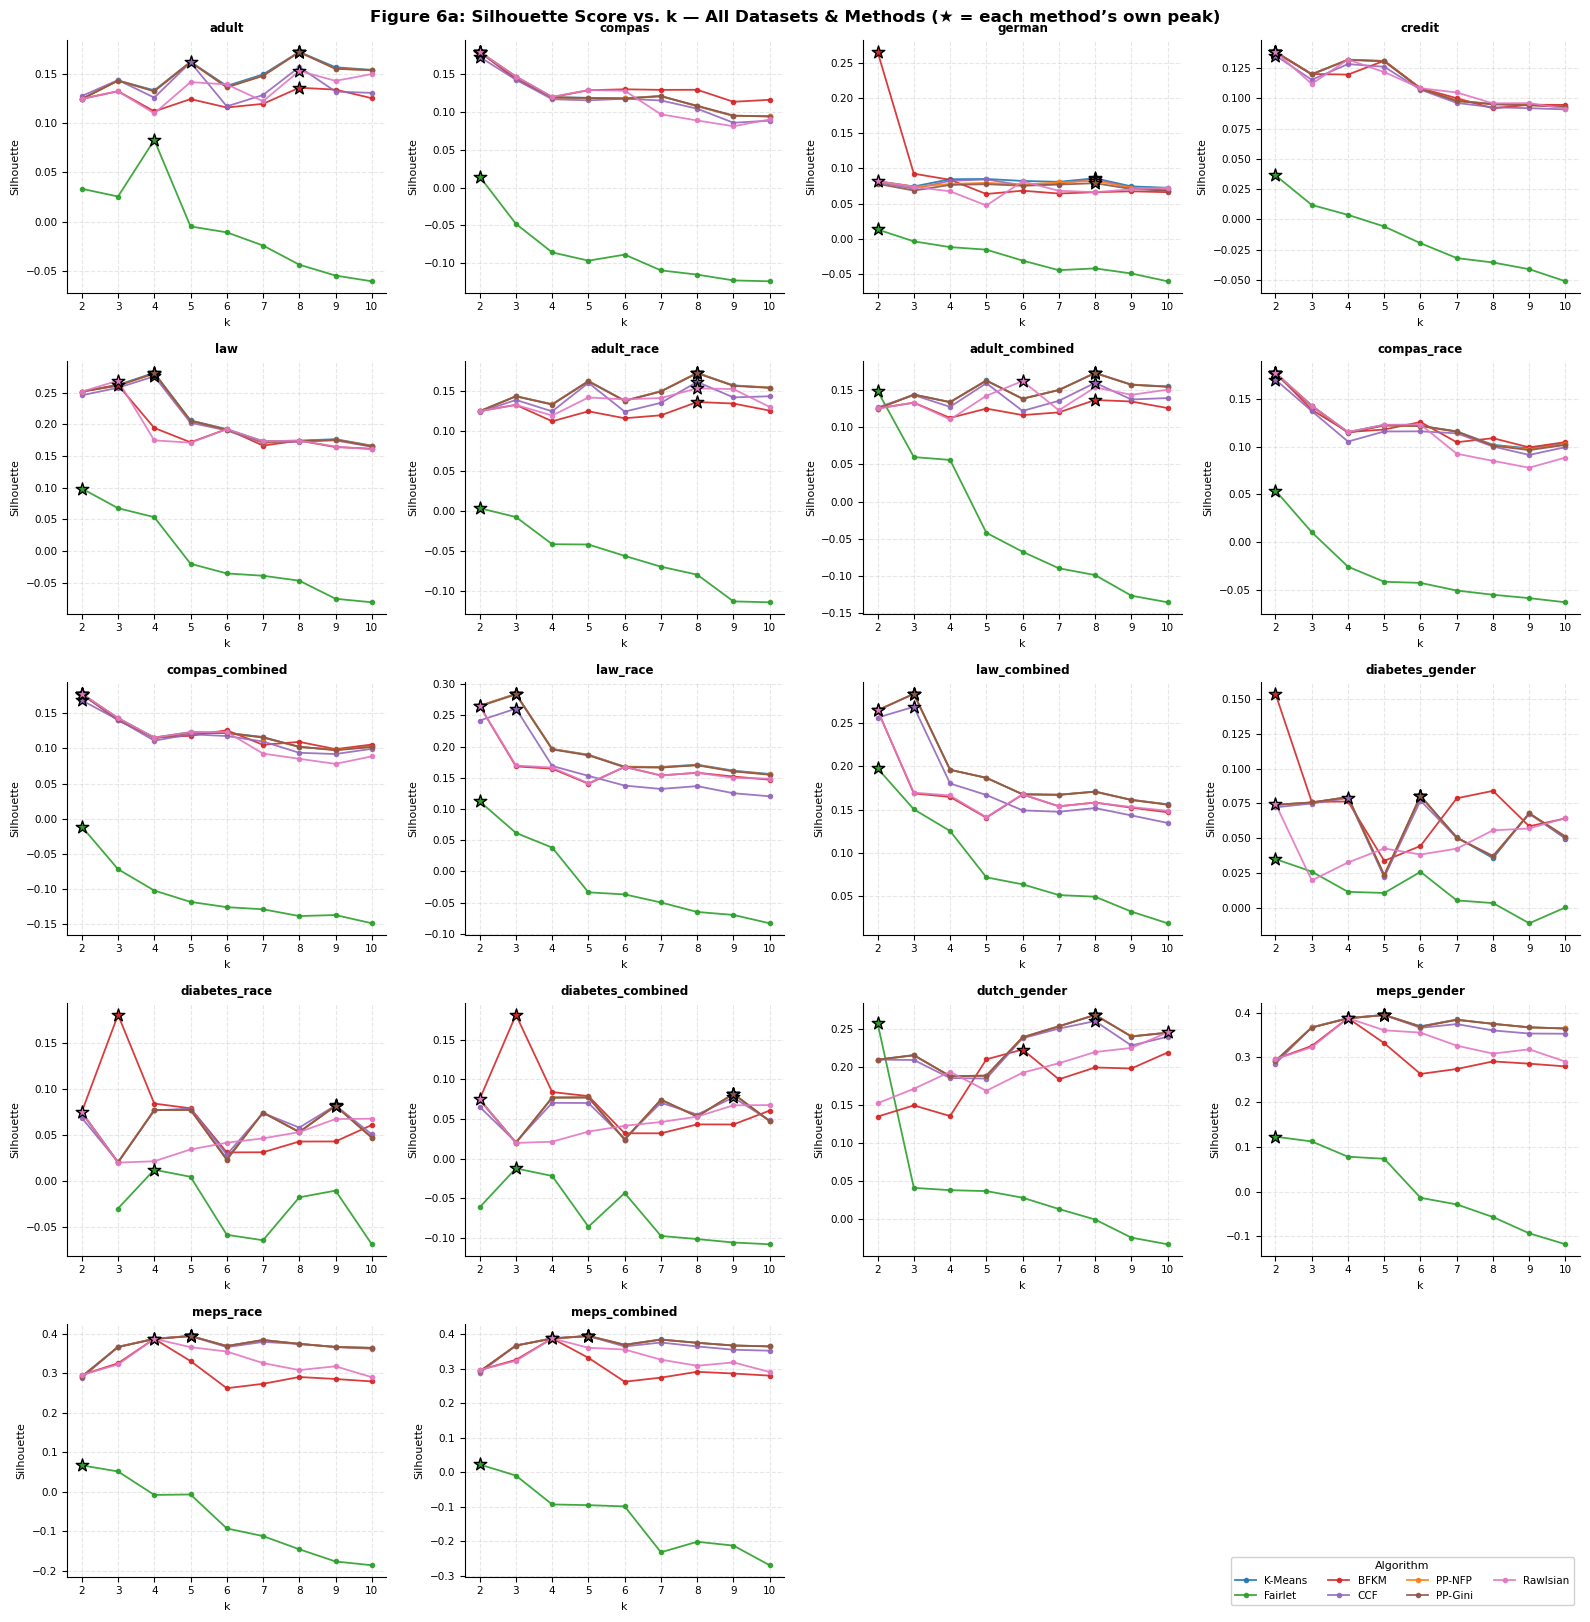

Saved Figure6a_k_sensitivity_silhouette_grid.png


In [6]:
def compact_grid(metric, ylabel, fname, title):
    N_COLS = 4
    N_ROWS = -(-len(datasets) // N_COLS)
    fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(16, 3.3*N_ROWS), squeeze=False)
    fig.suptitle(title, fontsize=12, fontweight='bold')

    for di, ds in enumerate(datasets):
        ax = axes[di // N_COLS][di % N_COLS]
        for ci, method in enumerate(methods):
            recs = [r for r in sweep[ds][method] if r['status'] == 'ok']
            xs = [r['k'] for r in recs]
            ys = [r[metric] for r in recs]
            ax.plot(xs, ys, marker='o', markersize=3, linewidth=1.3,
                    color=COLORS[ci % len(COLORS)], label=METHOD_LABEL[method], alpha=0.9)
            if metric == 'Silhouette' and ys:
                best_i = int(np.argmax(ys))
                ax.scatter([xs[best_i]], [ys[best_i]], marker='*', s=90,
                           color=COLORS[ci % len(COLORS)], edgecolor='black', zorder=5)
        ax.set_title(ds, fontsize=8.5, fontweight='bold')
        ax.set_xlabel('k', fontsize=8)
        ax.set_ylabel(ylabel, fontsize=8)
        ax.set_xticks(k_vals)
        ax.tick_params(labelsize=7.5)
        ax.grid(True, alpha=0.3, linestyle='--')

    for di in range(len(datasets), N_ROWS * N_COLS):
        axes[di // N_COLS][di % N_COLS].axis('off')

    handles, labels_ = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc='lower right', fontsize=7.5, ncol=4,
               title='Algorithm', title_fontsize=8,
               bbox_to_anchor=(0.99, 0.01), framealpha=0.9)

    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved', fname)

compact_grid('Silhouette', 'Silhouette',
             'Figure6a_k_sensitivity_silhouette_grid.png',
             'Figure 6a: Silhouette Score vs. k — All Datasets & Methods (\u2605 = each method\u2019s own peak)')

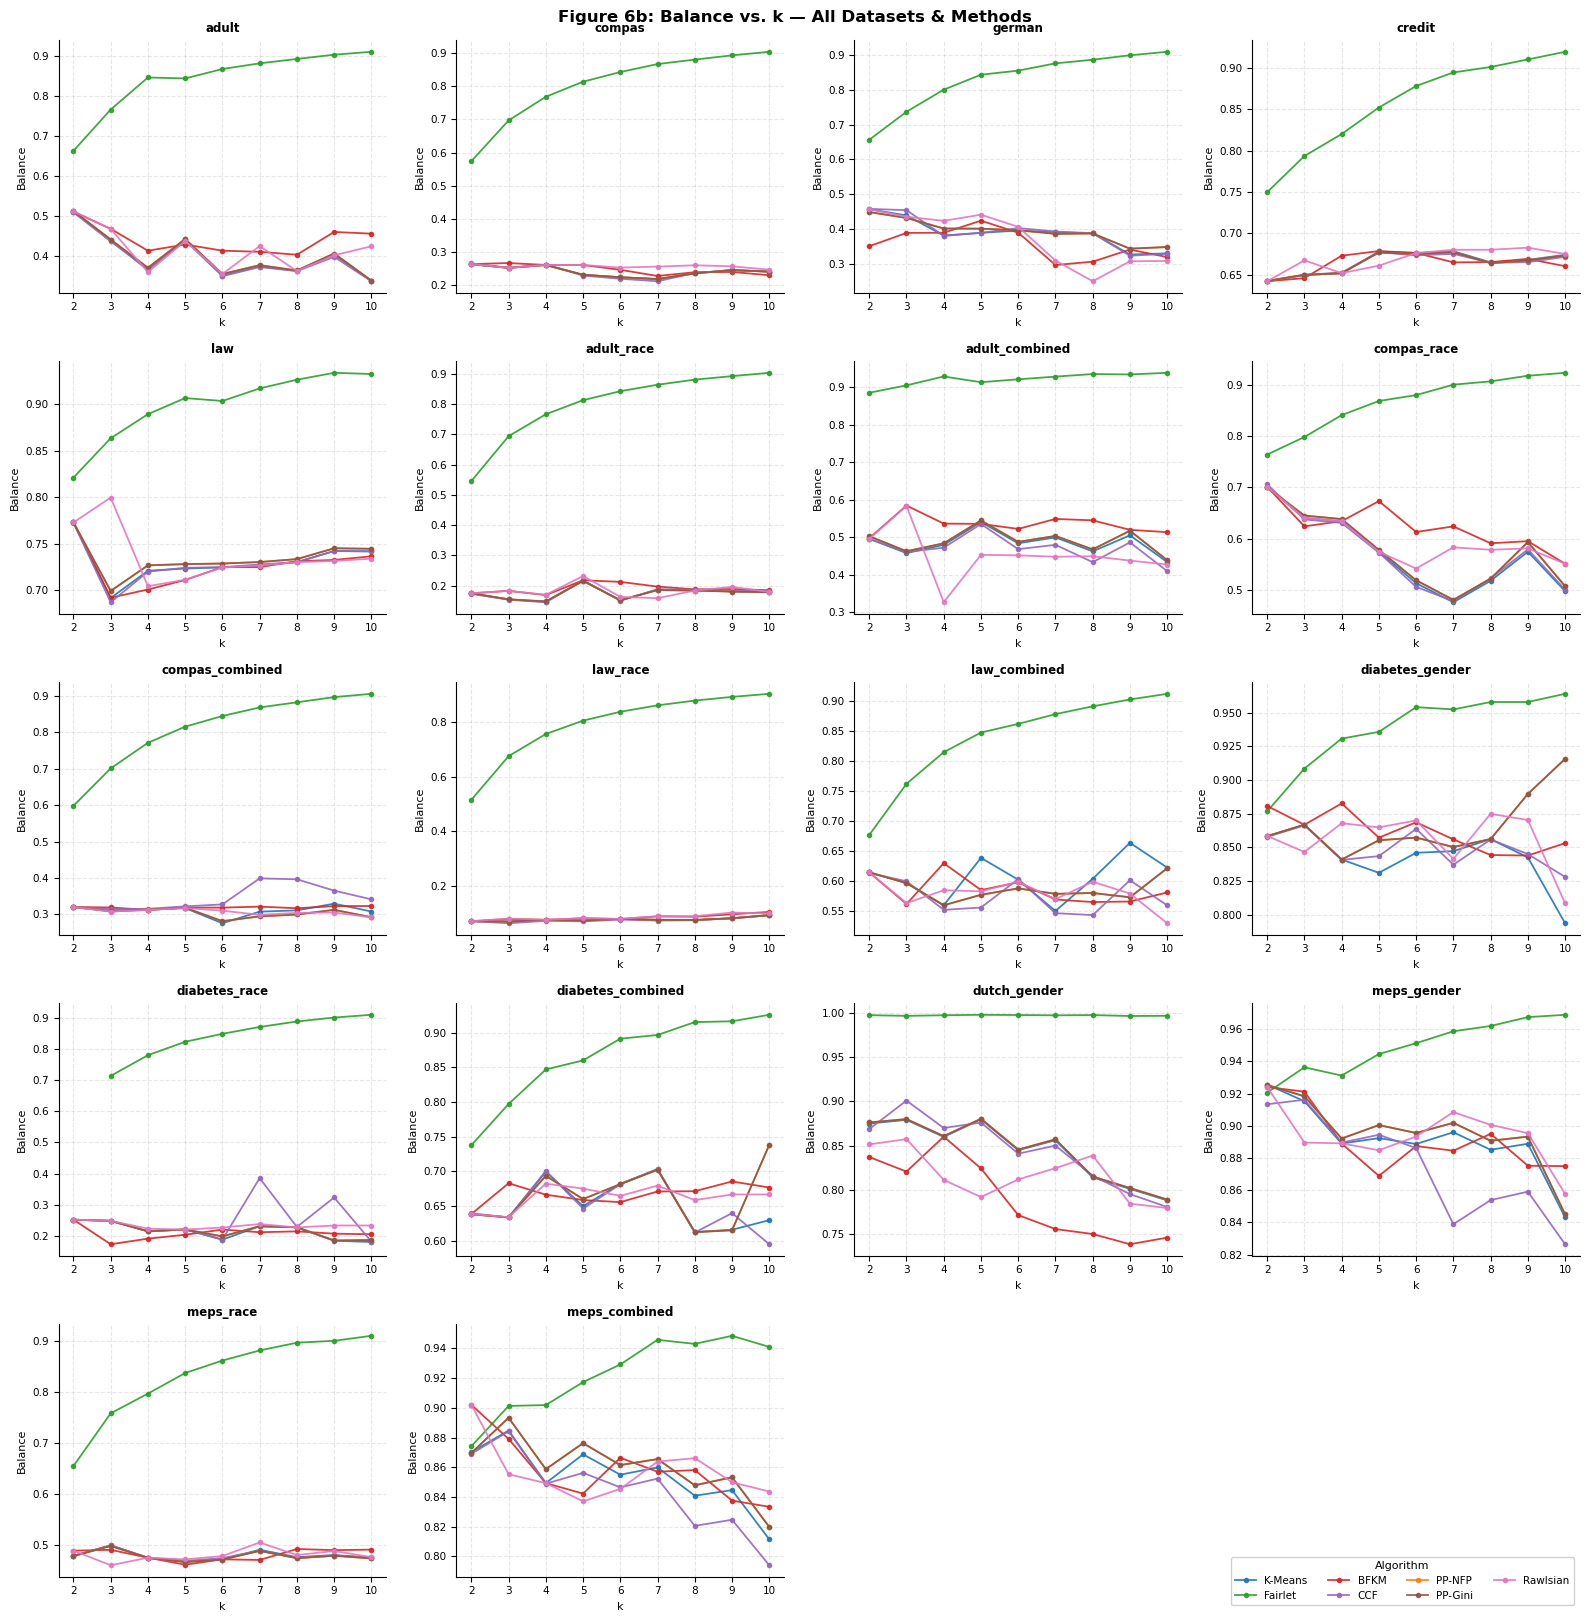

Saved Figure6b_k_sensitivity_balance_grid.png


In [7]:
compact_grid('Balance', 'Balance',
             'Figure6b_k_sensitivity_balance_grid.png',
             'Figure 6b: Balance vs. k — All Datasets & Methods')

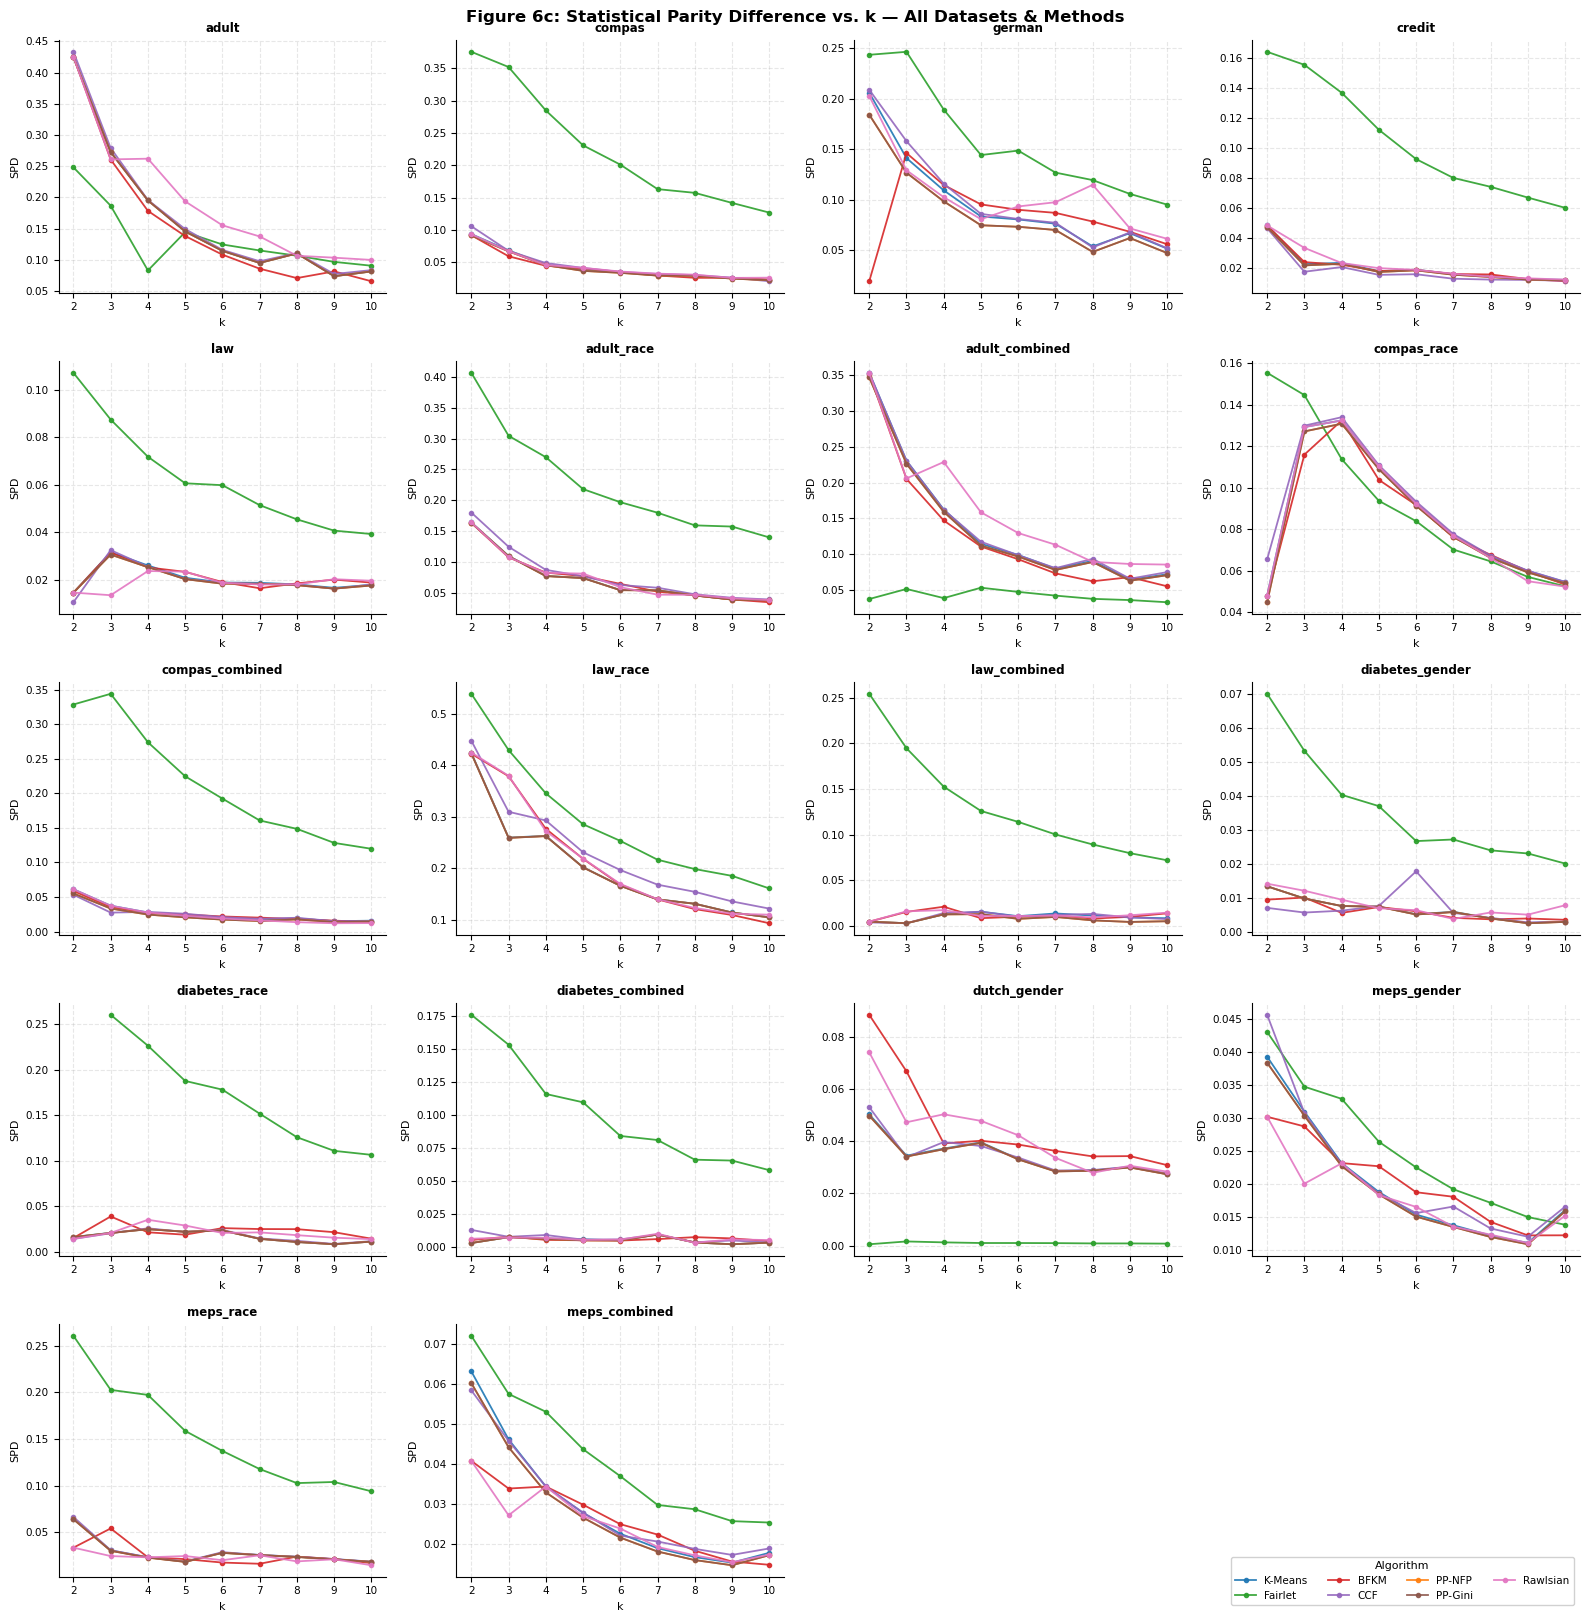

Saved Figure6c_k_sensitivity_spd_grid.png


In [8]:
compact_grid('SPD', 'SPD',
             'Figure6c_k_sensitivity_spd_grid.png',
             'Figure 6c: Statistical Parity Difference vs. k — All Datasets & Methods')

## Summary table + k-range justification statistic
For every (dataset, method): best k by Silhouette, values at k=2 / best k / k=10, and the full range (max−min) for Silhouette, Balance, and SPD across k=2–10.

Also computes the % of (dataset, method) pairs whose Silhouette optimum sits strictly **inside** k=2–10 rather than on the upper edge (k=10) — direct empirical evidence for whether the candidate range is wide enough.

In [10]:
rows = []
edge_hits = 0
total = 0
for ds in datasets:
    for m in methods:
        recs = [r for r in sweep[ds][m] if r['status'] == 'ok']
        if not recs:
            continue
        ks   = [r['k'] for r in recs]
        sils = [r['Silhouette'] for r in recs]
        bals = [r['Balance'] for r in recs]
        spds = [r['SPD'] for r in recs]
        best_i = int(np.argmax(sils))
        best_k = ks[best_i]
        total += 1
        if best_k == max(k_range):
            edge_hits += 1
        rows.append({
            'Dataset': ds, 'Method': METHOD_LABEL[m],
            'Best_k(Silhouette)': best_k,
            'Sil@k=2': round(recs[0]['Silhouette'], 4),
            'Sil@best_k': round(sils[best_i], 4),
            'Sil@k=10': round(recs[-1]['Silhouette'], 4),
            'Sil_range(max-min)': round(max(sils) - min(sils), 4),
            'Bal@k=2': round(recs[0]['Balance'], 4),
            'Bal@best_k': round(bals[best_i], 4),
            'Bal@k=10': round(recs[-1]['Balance'], 4),
            'Bal_range(max-min)': round(max(bals) - min(bals), 4),
            'SPD@k=2': round(recs[0]['SPD'], 4),
            'SPD@best_k': round(spds[best_i], 4),
            'SPD@k=10': round(recs[-1]['SPD'], 4),
            'SPD_range(max-min)': round(max(spds) - min(spds), 4),
        })

summary_df = pd.DataFrame(rows)
summary_df.to_csv('k_sensitivity_summary_full.csv', index=False)
summary_df.to_excel('k_sensitivity_summary_full.xlsx', index=False)

print(f"Combos where Silhouette peaks AT the upper edge (k=10): {edge_hits}/{total} "
      f"({100*edge_hits/total:.1f}%)")
print(f"=> {100*(1-edge_hits/total):.1f}% of dataset\u00d7method combinations reach their "
      f"Silhouette optimum strictly WITHIN k=2-10.")
summary_df.head(10)

Combos where Silhouette peaks AT the upper edge (k=10): 1/126 (0.8%)
=> 99.2% of dataset×method combinations reach their Silhouette optimum strictly WITHIN k=2-10.


,Dataset,Method,Best_k(Silhouette),Sil@k=2,Sil@best_k,Sil@k=10,Sil_range(max-min),Bal@k=2,Bal@best_k,Bal@k=10,Bal_range(max-min),SPD@k=2,SPD@best_k,SPD@k=10,SPD_range(max-min)
0,adult,K-Means,8,0.1247,0.1725,0.1542,0.0478,0.5112,0.3627,0.3375,0.1737,0.4253,0.1102,0.0813,0.3517
1,adult,Fairlet,4,0.0334,0.0830,-0.0607,0.1437,0.6628,0.8466,0.9108,0.2480,0.2481,0.0827,0.0904,0.1654
2,adult,BFKM,8,0.1247,0.1361,0.1254,0.0240,0.5110,0.4030,0.4557,0.1080,0.4256,0.0705,0.0655,0.3602
3,adult,CCF,5,0.1276,0.1619,0.1308,0.0448,0.5089,0.4385,0.3366,0.1723,0.4333,0.1491,0.0833,0.3563
4,adult,PP-NFP,8,0.1246,0.1723,0.1541,0.0477,0.5124,0.3635,0.3382,0.1741,0.4246,0.1100,0.0812,0.3511
5,adult,PP-Gini,8,0.1245,0.1722,0.1539,0.0477,0.5124,0.3635,0.3382,0.1741,0.4246,0.1100,0.0812,0.3511
6,adult,Rawlsian,8,0.1247,0.1531,0.1500,0.0431,0.5112,0.3621,0.4241,0.1564,0.4253,0.1063,0.0997,0.3256
7,compas,K-Means,2,0.1795,0.1795,0.0946,0.0849,0.2622,0.2622,0.2396,0.0456,0.0938,0.0938,0.0230,0.0709
8,compas,Fairlet,2,0.0146,0.0146,-0.1238,0.1384,0.5735,0.5735,0.9047,0.3312,0.3757,0.3757,0.1271,0.2485
9,compas,BFKM,2,0.1793,0.1793,0.1161,0.0659,0.2622,0.2622,0.2286,0.0392,0.0921,0.0921,0.0237,0.0684
